# Linear Regression

In this notebook the linear_regression module from the rice_ml package is used to predict the number of rings on an abalone.  
Two methods are used: closed-form solution using the Normal Equation, and using Stochastic Gradient Descent in an iterative solution
Prediction: 

In [17]:
import numpy as np
import pandas as pd

from rice_ml.supervised_learning import LinearRegression

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score

# Dataset Loading

We use the Abalone data set from UCI. The dataset includes 4177 samples and 9 features.
- Sex
- Length
- Diameter
- Height
- Whole Weight
- Shucked Weight
- Viscera Weight
- Shell Weight
- Rings

The data is loaded into a pandas dataframe.

In [18]:
input_file = "abalone.data"
columns = [
    'Sex', 'Length', 'Diameter', 'Height', 'Whole weight',
    'Shucked weight', 'Viscera weight', 'Shell weight', 'Rings'
]
df = pd.read_csv(input_file, header=None, names=columns)

df

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


# Dataset Preprocessing

The data is then placed into feature matrix `X` and label vector `y`. The Sex feature is removed from the dataset, as it is not useful for predictions. 

In [19]:
X = df.drop(['Sex', "Rings"], axis=1)
X = df[['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight']] 
y = df['Rings']

The data is split between training and testing data at an 80/20 ratio.
The sci-kit scaler is applied in order to standardize feature magnitude.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=30
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training
The first model solves the normal equation for an analytical solution.
The second model uses Stochastic Gradient Descent for an iterative solution. 

In [21]:
nmodel = LinearRegression()
nmodel.train_normal(X_train_scaled, y_train) 

model = LinearRegression()
model.train_gd(X_train_scaled, y_train)

# Prediction
The model makes predictions for the remaining testing data. The plots show the predicted number of rings compared to the actual number of rings at each data point.

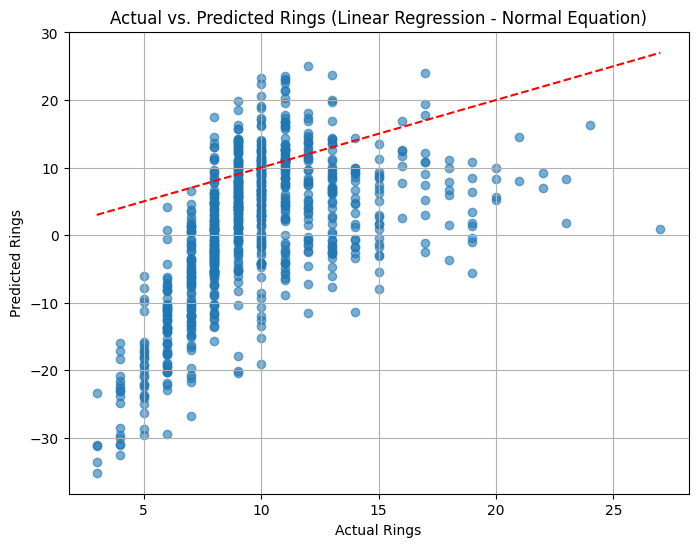

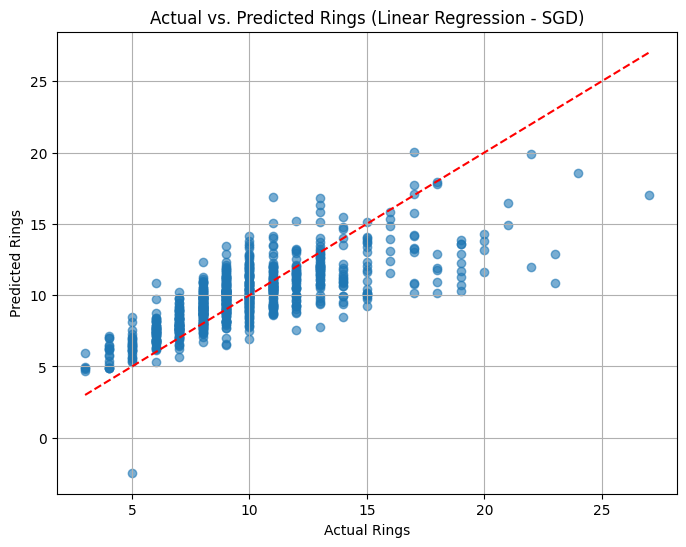

In [22]:
y_pred_normal = nmodel.predict(X_test_scaled)
y_pred = model.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(x=y_test, y=y_pred_normal, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("Actual vs. Predicted Rings (Linear Regression - Normal Equation)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("Actual vs. Predicted Rings (Linear Regression - SGD)")
plt.grid(True)
plt.show()

# Evaluation:
The 2 models are evaluated using R2 score and mean squared error.

In [23]:
mse_normal = mean_squared_error(y_test, y_pred_normal)
print("MSE (Normal Equation):", mse_normal)
print("MSE (Gradient Descent):", mean_squared_error(y_test, y_pred))
print("Normal Equation R^2 Score:", r2_score(y_test, y_pred_normal))
print("GD R^2 Score:", r2_score(y_test, y_pred))


MSE (Normal Equation): 167.93735557979872
MSE (Gradient Descent): 4.763690202554287
Normal Equation R^2 Score: -14.404553805649895
GD R^2 Score: 0.563036337059472


# Convergence:
 A graph shows the number of errors occuring over each iteration of the stochastic gradient descent model.

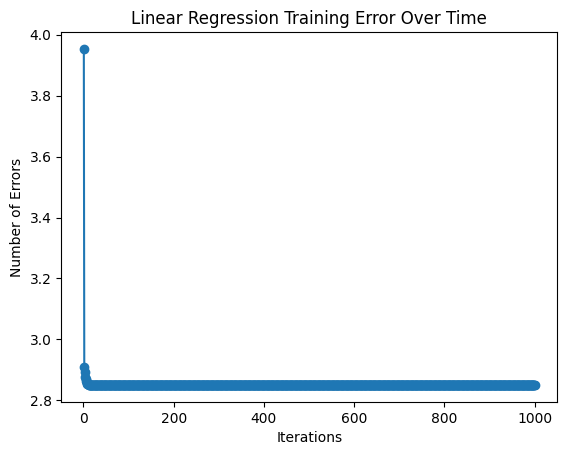

In [24]:
plt.plot(range(1, len(model.errors_) + 1), model.errors_, marker='o')
plt.xlabel('Iterations')
plt.ylabel('Number of Errors')
plt.title('Linear Regression Training Error Over Time')
plt.show()